# Credit Scoring - Model Development

This notebook focuses on developing and evaluating machine learning
models for predicting the probability of serious delinquency.

The prepared dataset from the preprocessing stage is used as input.

The main objective is to build a reliable baseline model, evaluate
its performance using appropriate classification metrics, compare
different algorithms, and select a final model for deployment.

## 1. Imports & Configuration

In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

TARGET = 'SeriousDlqin2yrs'
RANDOM_STATE = 42

In [26]:
X_train = pd.read_csv('data/X_train.csv')
X_valid = pd.read_csv('data/X_valid.csv')

y_train = pd.read_csv('data/y_train.csv').squeeze()
y_valid = pd.read_csv('data/y_valid.csv').squeeze()

## 2. Problem Definition

The target variable `SeriousDlqin2yrs` indicates whether a borrower
experienced a serious delinquency within the next two years.

This is a binary classification problem:

- 0 - no serious delinquency;
- 1 - serious delinquency.

The model should estimate the probability of class `1`, rather than
only returning a binary decision.

## 3. Data Validation

Before model training, the prepared datasets are checked for
structural consistency and unexpected missing or infinite values.

In [27]:
print('Missing values:')
print('Train:', X_train.isna().sum().sum())
print('Validation:', X_valid.isna().sum().sum())

print('\nInfinite values:')
print(
    'Train:',
    np.isinf(X_train.select_dtypes(include=np.number)).sum().sum()
)

print(
    'Validation:',
    np.isinf(X_valid.select_dtypes(include=np.number)).sum().sum()
)

Missing values:
Train: 0
Validation: 0

Infinite values:
Train: 0
Validation: 0


In [28]:
assert list(X_train.columns) == list(X_valid.columns)
assert len(X_train) == len(y_train)
assert len(X_valid) == len(y_valid)

print('Data validation passed.')

Data validation passed.


In [29]:
features = [
    'RevolvingUtilizationOfUnsecuredLines_log',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio_log',
    'MonthlyIncome_log',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    'HasUnknownDelinquencyHistory',
]

In [30]:
missing_features = [
    feature for feature in features
    if feature not in X_train.columns
]

assert not missing_features, (
    f'Missing features: {missing_features}'
)

print(f'Number of features: {len(features)}')

Number of features: 11


## 4. Baseline Model — Logistic Regression

In [31]:
numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')
            ),
                (
                    'scaler',
                    StandardScaler()
                )
            ]),
            numeric_features
        )
    ]
)

In [32]:
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

In [33]:
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [34]:
baseline_pipeline.fit(
    X_train[features],
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['RevolvingUtilizationOfUnsecuredLines_log','age', 'NumberOfTime30-59DaysPastDueNotWorse',..., 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents', 'HasUnknownDelinquencyHistory']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the

In [35]:
y_valid_proba = baseline_pipeline.predict_proba(
    X_valid[features]
)[:, 1]

## 5. Model Evaluation

The baseline model is evaluated using metrics suitable for an imbalanced
binary classification problem.

The main metrics are ROC-AUC and PR-AUC. Additional metrics and the
confusion matrix are used to understand the model's classification
behavior.

In [36]:
roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

print(f'Validation ROC-AUC: {roc_auc:.4f}')

Validation ROC-AUC: 0.8322


In [37]:
pr_auc = average_precision_score(
    y_valid,
    y_valid_proba
)

print(f'Validation PR-AUC: {pr_auc:.4f}')

Validation PR-AUC: 0.3566


In [38]:
DEFAULT_THRESHOLD = 0.5

y_valid_pred = (
    y_valid_proba >= DEFAULT_THRESHOLD
).astype(int)

In [39]:
print(
    classification_report(
        y_valid,
        y_valid_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9427    0.9923    0.9669     19571
           1     0.5822    0.1504    0.2390      1390

    accuracy                         0.9365     20961
   macro avg     0.7624    0.5713    0.6029     20961
weighted avg     0.9188    0.9365    0.9186     20961



## 6. Confusion Matrix

The confusion matrix shows how the model's predictions are distributed
between correct and incorrect classifications.

In [40]:
cm = confusion_matrix(
    y_valid,
    y_valid_pred
)

cm

array([[19421,   150],
       [ 1181,   209]])

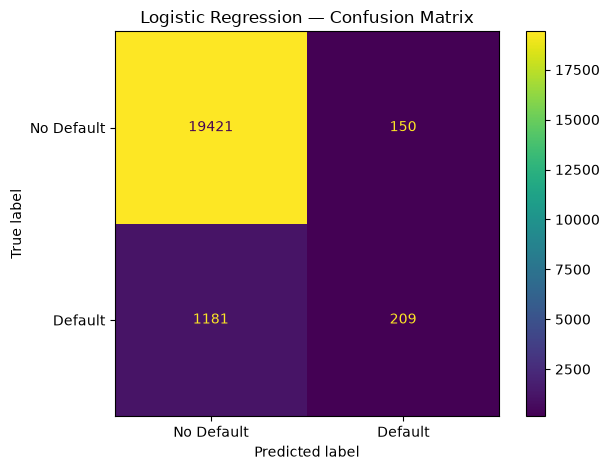

In [41]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Default', 'Default']
)

disp.plot()
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()